In [1]:
import requests
import pandas as pd
import os
import json
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
def load_data_from_api():
    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming"

    # 데이터 저장 폴더 생성 [cite: 15]
    if not os.path.exists('data'):
        os.makedirs('data')

    # API 호출 [cite: 13]
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()

        # JSON 파일로 저장 [cite: 15]
        with open('data/launches.json', 'w') as f:
            json.dump(data, f)

        # DataFrame으로 변환 및 반환 [cite: 16]
        df = pd.DataFrame(data['results'])
        print(f"데이터 수집 완료: {len(df)}건")
        return df
    else:
        print("API 호출 실패")
        return None

df_launches = load_data_from_api()
df_launches.head()

데이터 수집 완료: 10건


,id,url,launch_library_id,slug,name,status,net,window_end,window_start,inhold,...,failreason,hashtag,launch_service_provider,rocket,mission,pad,webcast_live,image,infographic,program
0,2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd,https://ll.thespacedevs.com/2.0.0/launch/2e3e3...,None,long-march-8a-satnet-leo-group-20,Long March 8A | SatNet LEO Group 20,"{'id': 3, 'name': 'Success'}",2026-03-12T19:48:00Z,2026-03-12T20:05:00Z,2026-03-12T19:40:00Z,False,...,,None,"{'id': 88, 'url': 'https://ll.thespacedevs.com...","{'id': 8933, 'configuration': {'id': 518, 'lau...","{'id': 7528, 'launch_library_id': None, 'name'...","{'id': 218, 'url': 'https://ll.thespacedevs.co...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,[]
1,1d24bfe7-d524-41f0-85de-09e967618710,https://ll.thespacedevs.com/2.0.0/launch/1d24b...,None,long-march-2d-shiyan-30-03-04,Long March 2D | Shiyan 30 03-04,"{'id': 3, 'name': 'Success'}",2026-03-12T22:33:00Z,2026-03-12T22:46:00Z,2026-03-12T22:25:00Z,False,...,,None,"{'id': 88, 'url': 'https://ll.thespacedevs.com...","{'id': 8934, 'configuration': {'id': 17, 'laun...","{'id': 7529, 'launch_library_id': None, 'name'...","{'id': 66, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,[]
2,6f2868b8-1000-48e5-893b-700c1371b4fb,https://ll.thespacedevs.com/2.0.0/launch/6f286...,None,falcon-9-block-5-starlink-group-10-48,Falcon 9 Block 5 | Starlink Group 10-48,"{'id': 1, 'name': 'Go'}",2026-03-13T12:10:40Z,2026-03-13T14:00:00Z,2026-03-13T10:00:00Z,False,...,,None,"{'id': 121, 'url': 'https://ll.thespacedevs.co...","{'id': 8928, 'configuration': {'id': 164, 'lau...","{'id': 7522, 'launch_library_id': None, 'name'...","{'id': 80, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,"[{'id': 25, 'url': 'https://ll.thespacedevs.co..."
3,d44f47c7-5e3e-40fb-9d10-b6e851acf81a,https://ll.thespacedevs.com/2.0.0/launch/d44f4...,None,falcon-9-block-5-starlink-group-17-31,Falcon 9 Block 5 | Starlink Group 17-31,"{'id': 1, 'name': 'Go'}",2026-03-13T14:33:50Z,2026-03-13T14:58:00Z,2026-03-13T10:58:00Z,False,...,,None,"{'id': 121, 'url': 'https://ll.thespacedevs.co...","{'id': 8922, 'configuration': {'id': 164, 'lau...","{'id': 7514, 'launch_library_id': None, 'name'...","{'id': 16, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,"[{'id': 25, 'url': 'https://ll.thespacedevs.co..."
4,f8766455-2b03-4629-a36e-b931c8b4a6c5,https://ll.thespacedevs.com/2.0.0/launch/f8766...,None,long-march-6a-unknown-payload,Long March 6A | Unknown Payload,"{'id': 1, 'name': 'Go'}",2026-03-15T13:20:00Z,2026-03-15T13:35:00Z,2026-03-15T13:14:00Z,False,...,,None,"{'id': 88, 'url': 'https://ll.thespacedevs.com...","{'id': 8935, 'configuration': {'id': 478, 'lau...","{'id': 7530, 'launch_library_id': None, 'name'...","{'id': 200, 'url': 'https://ll.thespacedevs.co...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,[]


In [5]:
def get_pictures():
    # 저장 폴더 생성 [cite: 21]
    if not os.path.exists('images'):
        os.makedirs('images')

    # JSON 파일 읽기 [cite: 18]
    with open('data/launches.json', 'r') as f:
        data = json.load(f)

    results = data.get('results', [])

    for i, launch in enumerate(results):
        image_url = launch.get('image') # 이미지 URL 추출 [cite: 19]

        if image_url:
            try:
                # 이미지 다운로드 예외 처리 [cite: 22]
                img_data = requests.get(image_url).content
                file_name = f"images/launch_{i}.jpg"

                with open(file_name, 'wb') as handler:
                    handler.write(img_data)
                print(f"저장 완료: {file_name}")
            except Exception as e:
                print(f"다운로드 실패 ({image_url}): {e}")
        else:
            print(f"{i}번 항목: 이미지가 없습니다.") [cite: 20]

get_pictures()

저장 완료: images/launch_0.jpg
저장 완료: images/launch_1.jpg
저장 완료: images/launch_2.jpg
저장 완료: images/launch_3.jpg
저장 완료: images/launch_4.jpg
저장 완료: images/launch_5.jpg
저장 완료: images/launch_6.jpg
저장 완료: images/launch_7.jpg
저장 완료: images/launch_8.jpg
저장 완료: images/launch_9.jpg


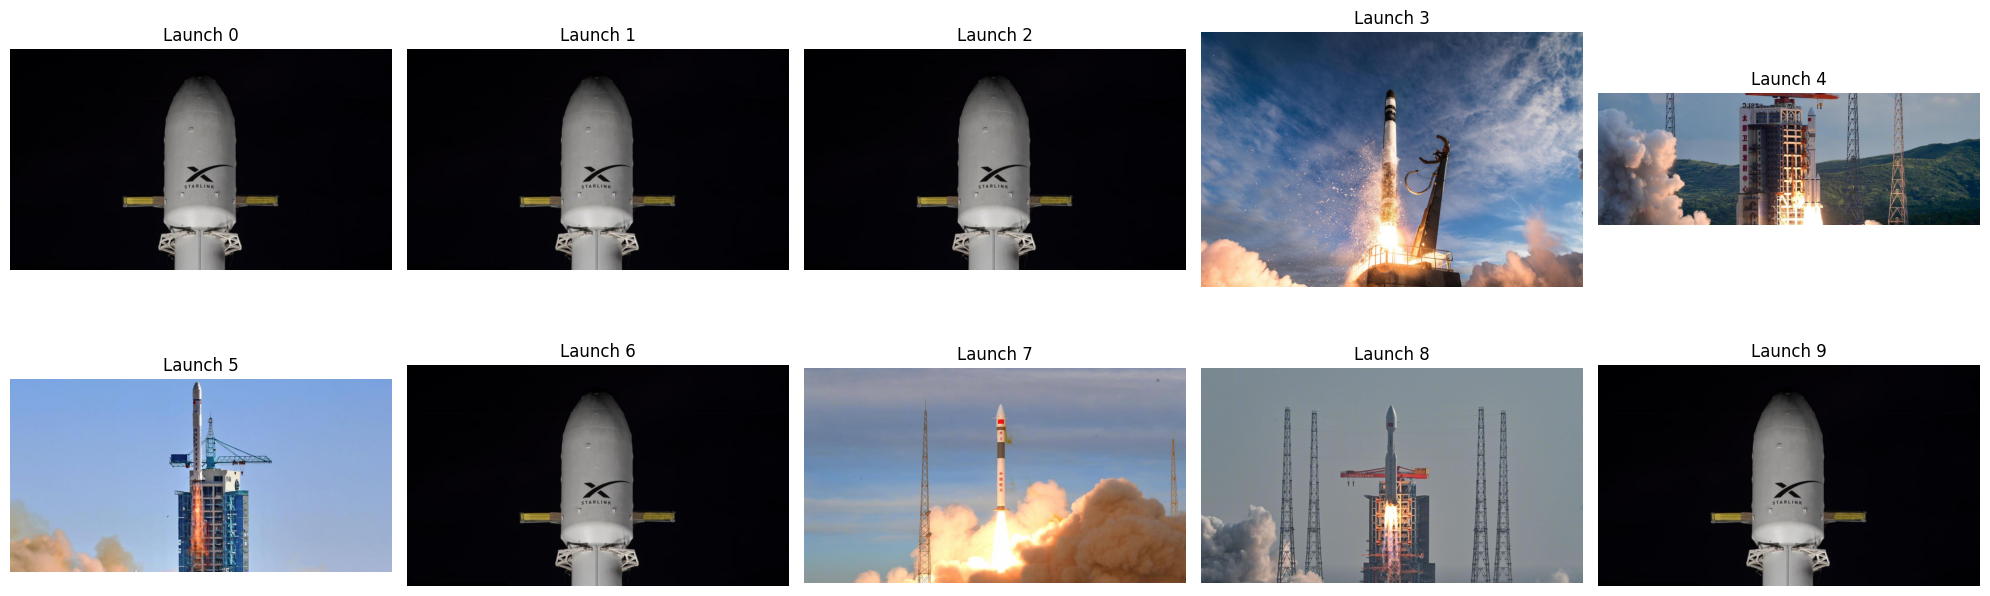

In [6]:
def visualize_images():
    image_files = [f"images/{file}" for file in os.listdir('images') if file.endswith('.jpg')]

    # 최대 10개(또는 50개 추천) 이미지 시각화 [cite: 4]
    plt.figure(figsize=(20, 10))
    for i, img_path in enumerate(image_files[:15]): # 예시로 15개 출력
        img = Image.open(img_path)
        plt.subplot(3, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Launch {i}")

    plt.tight_layout()
    plt.show()

visualize_images()